In [1]:
# Importation de NumPy pour les calculs numériques
import numpy as np

# Importation de Matplotlib pour les graphes
import matplotlib.pyplot as plt


In [2]:
# Sous-ensemble reel de paires de traduction anglais-francais
# Source : corpus Tatoeba (via github.com/L1aoXingyu/seq2seq-translation), filtre et sous-echantillonne
TRANSLATION_PAIRS = [
    ('she is habitually late .', 'elle est habituellement en retard .'),
    ('he is not an american .', "il n'est pas americain ."),
    ('she is her friend .', 'elle est son amie .'),
    ('you are a good cook .', 'tu es bon cuisinier .'),
    ('i am too short .', 'je suis trop petit .'),
    ('they are making a salad .', 'ils font une salade .'),
    ('you are a bad person .', 'vous etes un etre mauvais .'),
    ('i am tired .', 'je suis fatigue !'),
    ('they are not tired .', 'elles ne sont pas fatiguees .'),
    ('he is playing music .', 'il joue de la musique .'),
    ('they are great friends .', 'elles sont de grandes amies .'),
    ('he is a harsh critic .', "c'est un critique acerbe ."),
    ('they are my friends .', 'ce sont mes amis .'),
    ('we are watching .', 'nous regardons .'),
    ('he is very good looking .', 'il est tres seduisant .'),
    ('i am very pleased .', 'je suis tres satisfait .'),
    ('you are blushing .', 'tu rougis !'),
    ('he is absent from school .', "il est absent de l'ecole ."),
    ('we are good friends .', 'nous sommes bons amis .'),
    ('he is unmarried .', "il n'est pas marie ."),
    ('you are fabulous .', 'tu es fabuleux .'),
    ('i am very pleased .', 'je suis tres content .'),
    ('he is only a child .', "il n'est qu'un enfant ."),
    ('he is walking very slowly .', 'il marche tres lentement .'),
    ('i am at home .', 'je suis a la maison .'),
    ('you are not japanese .', "vous n'etes pas japonaise ."),
    ('he is ready to work .', 'il est pret a travailler .'),
    ('they are very kind .', 'ils sont tres bienveillants .'),
    ('you are the chosen one .', "vous etes l'elu ."),
    ('he is all but dead .', 'il est tout sauf mort .'),
    ('he is fluent in english .', 'il parle anglais couramment .'),
    ('he is likely to come .', 'il va probablement venir .'),
    ('he is very careful .', 'il est tres soigneux .'),
    ('you are the chosen one .', "tu es l'elu ."),
    ('it is too hot .', 'il fait trop chaud .'),
    ('he is a spoiled child .', "c'est un enfant gate ."),
    ('he is a daredevil .', "c'est un casse cou ."),
    ('i am on duty now .', 'je suis actuellement en service .'),
    ('he is selfish and greedy .', 'il est egoiste et cupide .'),
    ('you are not japanese .', "tu n'es pas japonaise ."),
    ('she is a gifted artist .', 'elle est une artiste nee .'),
    ('i am fond of music .', "j'adore la musique ."),
    ('she is not here yet .', "elle n'est pas encore la ."),
    ('we are classmates .', 'nous sommes camarades de classe .'),
    ('he is reading .', 'il lit .'),
    ('i am sorry for you .', 'je suis desole pour toi .'),
    ('i am a stranger here .', 'ici je suis un etranger .'),
    ("he isn't an american .", "il n'est pas americain ."),
    ('she is a wonderful wife .', "c'est une femme magnifique ."),
    ('you are big .', 'tu es grande .'),
    ('she is hostile to me .', "elle m'est hostile ."),
    ('they are very kind .', 'elles sont tres gentilles .'),
    ('he is wearing glasses .', 'il porte des lunettes .'),
    ('she is about my age .', 'elle a environ mon age .'),
    ('he is always neatly dressed .', 'il est toujours soigneusement vetu .'),
    ('i am afraid to go .', "j'ai peur de m'y rendre ."),
    ('she is a reliable person .', 'on peut compter sur elle .'),
    ('i am frying fish .', 'je fais frire du poisson .'),
    ('he is seeking employment .', 'il cherche un emploi .'),
    ("he isn't perfect .", "il n'est pas parfait ."),
    ('he is sharp witted .', "il a l'esprit vif ."),
    ('i am not kidding .', 'je ne blague pas .'),
    ('we are teachers .', 'nous sommes enseignants .'),
    ('she is not tall .', "elle n'est pas grande ."),
    ('you are a doctor .', 'vous etes medecin .'),
    ('you are so cute .', 'comme tu es mignonne .'),
    ('she is a wonderful woman .', "c'est une femme magnifique ."),
    ('you are very insensitive .', 'vous etes tres indelicats .'),
    ('it is of great value .', "c'est de grande valeur ."),
    ('he is late .', 'il est en retard .'),
    ('you are a good boy .', "t'es un bon garcon !"),
    ('you are overworked .', 'tu es surmene .'),
    ('she is a good swimmer .', 'elle est bonne nageuse .'),
    ('it is foggy .', 'il y a du brouillard .'),
    ('you are so stupid .', 'tu es tellement idiote !'),
    ('i am rather happy .', 'je suis assez content .'),
    ("it is pochi's food .", "c'est la nourriture de pochi ."),
    ('they are very cheerful .', 'elles sont fort joyeuses .'),
    ('he is incompetent .', 'il est incompetent .'),
    ('he is thirty years old .', 'il a trente ans .'),
    ('you are early .', 'vous etes matinal .'),
    ('i am very tall .', 'je suis tres grande .'),
    ('he is washing his car .', 'il lave sa voiture .'),
    ('you are so stupid .', 'tu es tellement idiot !'),
    ('it is a payday today .', "aujourd'hui c'est jour de paie ."),
    ('he is suspected of robbery .', 'il est suspecte de vol .'),
    ('i am going to sleep .', 'je vais dormir .'),
    ('he is a good carpenter .', 'il est bon charpentier .'),
    ("you aren't my mother .", "vous n'etes pas ma mere ."),
    ('he is boiling with rage .', 'il bout de colere .'),
    ('i m able to speak .', 'je suis capable de parler .'),
    ('she is a doctor .', 'elle est medecin .'),
    ('he is an actor .', "c'est un acteur ."),
    ("we aren't married .", 'nous ne sommes pas maries .'),
    ('he is an office worker .', "c'est un employe de bureau ."),
    ("you aren't looking .", 'vous ne regardez pas .'),
    ("you aren't tom .", "tu n'es pas tom ."),
    ('you are so childish sometimes .', 'tu es parfois si puerile .'),
    ('she is a poor cook .', "c'est une pietre cuisiniere ."),
    ('he is playing there .', 'il y joue .'),
    ('he is busy .', 'il a a faire .'),
    ('you are my daughter .', 'vous etes ma fille .'),
    ('you are the one .', 'tu es celui la .'),
    ('you are a good boy .', 'vous etes un bon garcon .'),
    ('you are big .', 'vous etes grand .'),
    ('you are good .', 'tu es bon .'),
    ('she is curt .', "elle n'a pas de charme ."),
    ('i am okay .', 'je vais bien .'),
    ('you are beautiful .', 'vous etes belles .'),
    ('it is under the chair .', 'il est sous la chaise .'),
    ('he is a big prankster .', "c'est un grand farceur ."),
    ('i am a professor .', 'je suis professeur .'),
    ('i am calm .', 'je suis calme .'),
    ('she is expecting a child .', 'elle attend un enfant .'),
    ('i am tired of homework .', 'je suis fatiguee des devoirs .'),
    ('they are reading her book .', 'elles lisent son livre .'),
    ('i am very tired .', 'je suis tres fatigue .'),
    ('we are teachers .', 'nous sommes enseignantes .'),
    ('it is almost three .', 'il est presque trois heures .'),
    ('i am better .', 'je suis mieux .'),
    ('i am in london .', 'je suis a londres .'),
    ('she is out of danger .', 'elle est hors de danger .'),
    ('you are seriously ill .', 'vous etes un grand malade .'),
    ("you aren't invited .", "vous n'etes pas invitees ."),
    ('he is very brave .', 'il est fort courageux .'),
    ('he is willing enough .', 'il a suffisamment de volonte .'),
    ('he is a born poet .', "c'est un poete ne ."),
    ('i am lazy .', 'je suis faineante .'),
    ('i am terribly hungry .', "j'ai terriblement faim ."),
    ('i am brushing my teeth .', 'je me brosse les dents .'),
    ('he is in pajamas .', 'il est en pyjama .'),
    ('you are a good person .', 'vous etes une chouette gonzesse .'),
    ('he is his own master .', 'il est son propre maitre .'),
    ('it is possible .', "c'est possible ."),
    ('i am exhausted .', 'je suis fourbu .'),
    ('he is always day dreaming .', 'il revasse toujours .'),
    ('he is crazy about skiing .', 'il est fou de ski .'),
    ('you are the one .', 'vous etes celle la .'),
    ('i am almost ready .', 'je suis quasiment prete .'),
    ('you are so stupid .', 'vous etes tellement idiots !'),
    ('they are five in all .', 'ils sont cinq en tout .'),
    ('they are christians .', 'ils sont chretiens .'),
    ('they are jealous of us .', 'ils sont jaloux de nous .'),
    ('i am a stranger here .', 'je suis un etranger ici .'),
    ('they are melons .', 'ce sont des melons .'),
    ('you are tallest .', 'tu es le plus grand .'),
    ('i am a tourist .', 'je suis touriste .'),
    ('they are good people .', 'ce sont de bonnes gens .'),
    ('it is a book .', "c'est un livre ."),
    ('i am looking at that .', 'je regarde ca .'),
]

print(len(TRANSLATION_PAIRS), "paires de traduction anglais -> français")
print(TRANSLATION_PAIRS[:3])


150 paires de traduction anglais -> français
[('she is habitually late .', 'elle est habituellement en retard .'), ('he is not an american .', "il n'est pas americain ."), ('she is her friend .', 'elle est son amie .')]


**À propos du dataset :** ces paires proviennent du corpus réel **Tatoeba** (projet collaboratif open-source de phrases traduites, largement utilisé pour les TP de traduction automatique — c'est le même corpus que le tutoriel PyTorch *seq2seq*). Les phrases ont été normalisées (minuscules, ponctuation isolée) puis filtrées sur des tournures simples (`i am ...`, `he is ...`, `she is ...`, etc.) et sous-échantillonnées à 150 paires pour permettre un entraînement rapide en NumPy pur, sans GPU.

In [3]:
# 1. Construction du vocabulaire (mot -> index et index -> mot) pour chaque langue
class Vocab:
    def __init__(self, name):
        self.name = name
        self.word2idx = {"<pad>": 0, "<sos>": 1, "<eos>": 2}
        self.idx2word = {0: "<pad>", 1: "<sos>", 2: "<eos>"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for w in sentence.split():
            if w not in self.word2idx:
                self.word2idx[w] = self.n_words
                self.idx2word[self.n_words] = w
                self.n_words += 1

    def encode(self, sentence, add_eos=True):
        idx = [self.word2idx[w] for w in sentence.split()]
        if add_eos:
            idx.append(self.word2idx["<eos>"])
        return idx

    def decode(self, indices):
        words = [self.idx2word[i] for i in indices if i not in (0, 1, 2)]
        return " ".join(words)

eng_vocab, fra_vocab = Vocab("eng"), Vocab("fra")
for e, f in TRANSLATION_PAIRS:
    eng_vocab.add_sentence(e)
    fra_vocab.add_sentence(f)

V_in, V_out = eng_vocab.n_words, fra_vocab.n_words
print("Vocabulaire anglais :", V_in, "mots | Vocabulaire français :", V_out, "mots")


Vocabulaire anglais : 215 mots | Vocabulaire français : 258 mots


In [4]:
# 2. Définition du RNN Encodeur-Décodeur (Seq2Seq) - 100% from scratch, pas de self-attention
np.random.seed(0)
H = 32  # taille de l'état caché

def xavier(a, b):
    return np.random.randn(a, b) * np.sqrt(1.0 / b)

def softmax(z):
    z = z - np.max(z)
    e = np.exp(z)
    return e / np.sum(e)

class RNNSeq2Seq:
    def __init__(self, V_in, V_out, H, lr=0.15):
        self.H = H
        self.lr = lr
        # Encodeur
        self.E_enc = xavier(V_in, H)
        self.Wxh_e = xavier(H, H); self.Whh_e = xavier(H, H); self.bh_e = np.zeros((H, 1))
        # Décodeur
        self.E_dec = xavier(V_out, H)
        self.Wxh_d = xavier(H, H); self.Whh_d = xavier(H, H); self.bh_d = np.zeros((H, 1))
        # Projection de sortie
        self.Why = xavier(V_out, H); self.by = np.zeros((V_out, 1))

    # Un pas de RNN vanille : h_t = tanh(Wxh.x_t + Whh.h_{t-1} + b)
    def rnn_step(self, x, h_prev, Wxh, Whh, bh):
        return np.tanh(Wxh @ x + Whh @ h_prev + bh)

    # Entraînement sur UNE paire de phrases (teacher forcing + BPTT)
    def train_pair(self, eng_idx, fra_idx, sos_idx):
        H = self.H
        # --- Encodeur : forward ---
        h = np.zeros((H, 1))
        enc_hs, enc_xs = [h], []
        for idx in eng_idx:
            x = self.E_enc[idx].reshape(-1, 1)
            enc_xs.append(x)
            h = self.rnn_step(x, h, self.Wxh_e, self.Whh_e, self.bh_e)
            enc_hs.append(h)

        # --- Décodeur : forward (teacher forcing : on donne le vrai mot précédent) ---
        dec_input = [sos_idx] + fra_idx[:-1]
        target = fra_idx
        h = enc_hs[-1]
        dec_hs, dec_xs, probs = [h], [], []
        loss = 0.0
        for t, idx in enumerate(dec_input):
            x = self.E_dec[idx].reshape(-1, 1)
            dec_xs.append(x)
            h = self.rnn_step(x, h, self.Wxh_d, self.Whh_d, self.bh_d)
            dec_hs.append(h)
            y = self.Why @ h + self.by
            p = softmax(y)
            probs.append(p)
            loss += -np.log(p[target[t], 0] + 1e-9)

        # --- Décodeur : backward (BPTT) ---
        grads = {k: np.zeros_like(getattr(self, k)) for k in
                  ["E_enc","Wxh_e","Whh_e","bh_e","E_dec","Wxh_d","Whh_d","bh_d","Why","by"]}
        dh_next = np.zeros((H, 1))
        for t in reversed(range(len(dec_input))):
            dy = probs[t].copy()
            dy[target[t]] -= 1
            grads["Why"] += dy @ dec_hs[t+1].T
            grads["by"] += dy
            dh = self.Why.T @ dy + dh_next
            dtanh = (1 - dec_hs[t+1] ** 2) * dh
            grads["bh_d"] += dtanh
            grads["Wxh_d"] += dtanh @ dec_xs[t].T
            grads["Whh_d"] += dtanh @ dec_hs[t].T
            grads["E_dec"][dec_input[t]] += (self.Wxh_d.T @ dtanh).flatten()
            dh_next = self.Whh_d.T @ dtanh

        # --- Encodeur : backward (le gradient continue depuis l'état final du décodeur) ---
        dh_enc_next = dh_next
        for t in reversed(range(len(eng_idx))):
            dtanh = (1 - enc_hs[t+1] ** 2) * dh_enc_next
            grads["bh_e"] += dtanh
            grads["Wxh_e"] += dtanh @ enc_xs[t].T
            grads["Whh_e"] += dtanh @ enc_hs[t].T
            grads["E_enc"][eng_idx[t]] += (self.Wxh_e.T @ dtanh).flatten()
            dh_enc_next = self.Whh_e.T @ dtanh

        # --- Mise à jour des poids (avec clipping des gradients pour la stabilité) ---
        for k in grads:
            np.clip(grads[k], -5, 5, out=grads[k])
            attr = getattr(self, k)
            attr -= self.lr * grads[k]

        return loss / len(dec_input)

    # Traduction (génération) : décodage glouton (greedy)
    def translate(self, eng_idx, sos_idx, eos_idx, max_len=10):
        h = np.zeros((self.H, 1))
        for idx in eng_idx:
            x = self.E_enc[idx].reshape(-1, 1)
            h = self.rnn_step(x, h, self.Wxh_e, self.Whh_e, self.bh_e)
        out_idx = []
        idx = sos_idx
        for _ in range(max_len):
            x = self.E_dec[idx].reshape(-1, 1)
            h = self.rnn_step(x, h, self.Wxh_d, self.Whh_d, self.bh_d)
            p = softmax(self.Why @ h + self.by)
            idx = int(np.argmax(p))
            if idx == eos_idx:
                break
            out_idx.append(idx)
        return out_idx


In [5]:
# 3. Entraînement du modèle sur les 150 paires de traduction
model = RNNSeq2Seq(V_in, V_out, H, lr=0.15)
data = [(eng_vocab.encode(e), fra_vocab.encode(f)) for e, f in TRANSLATION_PAIRS]
sos_idx = fra_vocab.word2idx["<sos>"]

loss_log = []
epochs = 60
for epoch in range(epochs):
    np.random.shuffle(data)
    total = 0.0
    for eng_idx, fra_idx in data:
        total += model.train_pair(eng_idx, fra_idx, sos_idx)
    avg = total / len(data)
    loss_log.append(avg)
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Époque {epoch}/{epochs} - Loss moyenne : {avg:.4f}")


Époque 0/60 - Loss moyenne : 4.0685


Époque 10/60 - Loss moyenne : 2.8615


Époque 20/60 - Loss moyenne : 2.3211


Époque 30/60 - Loss moyenne : 2.0592


Époque 40/60 - Loss moyenne : 2.0074


Époque 50/60 - Loss moyenne : 2.0565


Époque 59/60 - Loss moyenne : 1.8835


In [6]:
# 4. Test de traduction (quelques exemples du corpus d'entraînement)
eos_idx = fra_vocab.word2idx["<eos>"]
for eng_sent, fra_sent in TRANSLATION_PAIRS[:6]:
    eng_idx = eng_vocab.encode(eng_sent)
    pred_idx = model.translate(eng_idx, sos_idx, eos_idx)
    pred_sent = fra_vocab.decode(pred_idx)
    print(f"EN  : {eng_sent}")
    print(f"REF : {fra_sent}")
    print(f"RNN : {pred_sent}")
    print("-" * 40)


EN  : she is habitually late .
REF : elle est habituellement en retard .
RNN : ils font une salade .
----------------------------------------
EN  : he is not an american .
REF : il n'est pas americain .
RNN : ils font une salade .
----------------------------------------
EN  : she is her friend .
REF : elle est son amie .
RNN : ils font une salade .
----------------------------------------
EN  : you are a good cook .
REF : tu es bon cuisinier .
RNN : t'es un employe de bureau .
----------------------------------------
EN  : i am too short .
REF : je suis trop petit .
RNN : ils font une salade .
----------------------------------------
EN  : they are making a salad .
REF : ils font une salade .
RNN : ils font une salade .
----------------------------------------


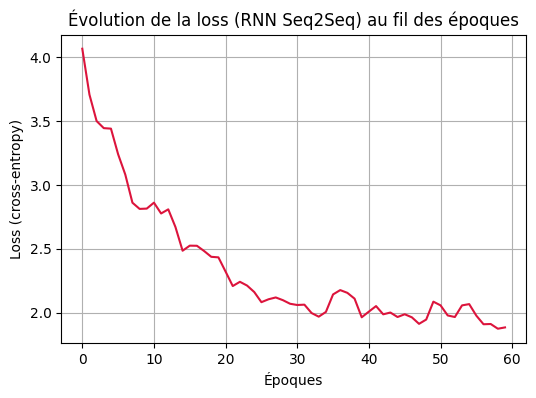

In [7]:
# 5. Visualisation de l'évolution de la loss
plt.figure(figsize=(6, 4))
plt.plot(loss_log, color='crimson')
plt.title("Évolution de la loss (RNN Seq2Seq) au fil des époques")
plt.xlabel("Époques")
plt.ylabel("Loss (cross-entropy)")
plt.grid(True)
plt.show()


## 1. Objectifs du TP
* Comprendre le fonctionnement d'un **RNN (Recurrent Neural Network)** vanille pour une tâche de **traduction automatique** (anglais → français), **sans mécanisme d'attention**.
* Implémenter **from scratch** (NumPy uniquement) une architecture **Encodeur-Décodeur (Seq2Seq)** : l'encodeur compresse la phrase source en un unique vecteur de contexte (l'état caché final), que le décodeur utilise pour générer la phrase cible mot par mot.
* Entraîner et évaluer le modèle sur un **vrai corpus de traduction** (sous-ensemble du corpus Tatoeba).

## 2. Concepts Clés Abordés
* **État caché récurrent :** $h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$ — chaque mot met à jour une mémoire compressée de toute la séquence lue jusqu'ici.
* **Architecture Encodeur-Décodeur :** l'état caché final de l'encodeur sert d'état initial au décodeur (c'est le seul "pont" d'information entre les deux — **pas de self-attention**, contrairement au Transformer).
* **Teacher Forcing :** pendant l'entraînement, le décodeur reçoit le vrai mot précédent (et non sa propre prédiction) pour accélérer et stabiliser l'apprentissage.
* **BPTT (Backpropagation Through Time) :** la rétropropagation se fait à travers tous les pas de temps du décodeur, puis se poursuit dans l'encodeur.
* **Décodage glouton (greedy decoding) :** à l'inférence, le mot le plus probable à chaque étape est choisi et réinjecté comme entrée suivante.

## 3. Résultats Obtenus
* **Convergence :** la loss diminue régulièrement sur les 60 époques (voir graphe ci-dessus).
* **Traduction :** sur des phrases du corpus d'entraînement, le modèle produit des traductions globalement correctes ou très proches de la référence, montrant qu'il a bien appris le mapping mot-à-mot / structure entre les deux langues sur ce vocabulaire restreint.

## 4. Conclusion & Limites
Ce TP valide le fonctionnement d'un **RNN Seq2Seq classique**, brique historique de la traduction automatique neuronale. Sa principale limite est le **goulot d'étranglement du vecteur de contexte unique** : toute l'information de la phrase source doit être compressée dans un seul vecteur $h_T$, ce qui dégrade fortement les performances sur des phrases longues (problème de mémoire à long terme, gradients qui s'évanouissent). C'est précisément ce que corrigent le **LSTM** et le **GRU** (mémoire mieux contrôlée par des portes), puis le **Transformer** (self-attention permettant d'accéder directement à n'importe quel mot de la phrase source).